In [3]:
import numpy as np 
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt 


In [4]:
np.random.seed(42) #seed fixed so as to get exact same dataset everytime
n_samples=100
cgpa = np.random.uniform(5.0, 10.0, n_samples) #Generating random features with cgpa between 5.0 and 10.0
resume_score = np.random.uniform(5.0, 10.0, n_samples) 

In [5]:
#If their (CGPA * 1.5) + Resume Score > 18.5, they get placed (1). Otherwise, they don't (0).
decision_boundary=(cgpa*1.5) + resume_score
placed=np.where(decision_boundary>18.5 , 1,0)

df = pd.DataFrame({
    'cgpa': np.round(cgpa, 2),
    'resume_score': np.round(resume_score, 2),
    'placed': placed
})

print(df.shape)
df.head()

(100, 3)


,cgpa,resume_score,placed
0,6.87,5.16,0
1,9.75,8.18,1
2,8.66,6.57,1
3,7.99,7.54,1
4,5.78,9.54,0


<Axes: xlabel='cgpa', ylabel='resume_score'>

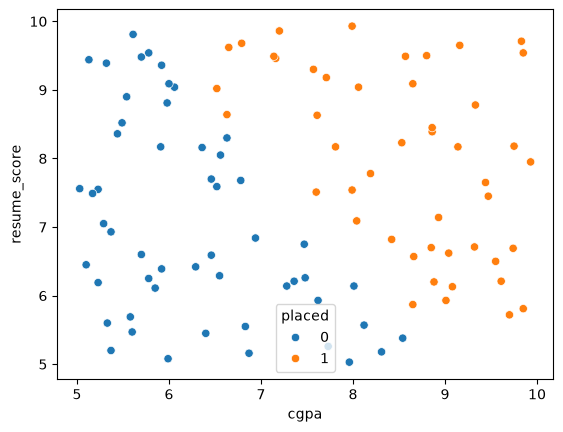

In [6]:
sns.scatterplot(x=df['cgpa'], y=df['resume_score'], hue=df['placed']) 

# we can also plot like this 

# Creating a new figure with a specific size
# plt.figure(figsize=(8, 6))

# # Plotting the dataset, coloring the dots based on the 'placed' column
# sns.scatterplot(x='cgpa', y='resume_score', hue='placed', data=df, s=100)

# # Add titles and labels for clarity
# plt.title("Student Placement Data (Linearly Separable)")
# plt.xlabel("CGPA")
# plt.ylabel("Resume Score")

# # Display the graph
# plt.show()

In [7]:
X = df.iloc[:, 0:2] 
#.iloc Tells pandas to locate data using its numerical index (0, 1, 2) rather than the column names.
#X: It is an ML standard to use a capital X to store your 2D matrix of input features.
y = df.iloc[:, -1]
#This line extracts your target answers (whether they were placed or not).
#y: It is an ML standard to use a lowercase y to store your 1D list of target answers.

In [8]:
# ==========================================
# INITIALIZING THE PERCEPTRON
# ==========================================

# Import the highly-optimized, production-ready Perceptron algorithm from Scikit-Learn.
from sklearn.linear_model import Perceptron

# Instantiate the model (create the "empty brain").
# This automatically configures default hyperparameters like the learning rate and max epochs.
p = Perceptron()

In [21]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
p = Perceptron()
p.fit(X_scaled, y)

,"penalty penalty: {'l2','l1','elasticnet'}, default=NoneThe penalty (aka regularization term) to be used.",None
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term if regularization isused.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with `0 <= l1_ratio <= 1`.`l1_ratio=0` corresponds to L2 penalty, `l1_ratio=1` to L1.Only used if `penalty='elasticnet'`... versionadded:: 0.24",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method... versionadded:: 0.19",1000
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, the iterations will stopwhen (loss > previous_loss - tol)... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.",0
,"eta0 eta0: float, default=1Constant by which the updates are multiplied.",1.0
,"n_jobs n_jobs: int, default=NoneThe number of CPUs to use to do the OVA (One Versus All, formulti-class problems) computation.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"random_state random_state: int, RandomState instance or None, default=0Used to shuffle the training data, when ``shuffle`` is set to``True``. Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",0


In [22]:
p.coef_

array([[3.19577488, 2.15955147]])

In [23]:
p.intercept_


array([0.])

In [1]:
!pip install mlxtend --user
#mlxtend (Machine Learning Extensions) is a very popular library that provides extra tools and helpers for everyday machine learning tasks.

  Using cached mlxtend-0.25.0-py3-none-any.whl.metadata (7.4 kB)
  Using cached matplotlib-3.11.0-cp313-cp313-win_amd64.whl.metadata (80 kB)
Using cached mlxtend-0.25.0-py3-none-any.whl (1.4 MB)
Using cached matplotlib-3.11.0-cp313-cp313-win_amd64.whl (9.3 MB)

   ---------------------------------------- 0/2 [matplotlib]
   ---------------------------------------- 0/2 [matplotlib]
   ---------------------------------------- 0/2 [matplotlib]
   ---------------------------------------- 0/2 [matplotlib]
   ---------------------------------------- 0/2 [matplotlib]
   ---------------------------------------- 0/2 [matplotlib]
   ---------------------------------------- 0/2 [matplotlib]
   ---------------------------------------- 0/2 [matplotlib]
   ---------------------------------------- 0/2 [matplotlib]
   ---------------------------------------- 0/2 [matplotlib]
   ---------------------------------------- 0/2 [matplotlib]
   ---------------------------------------- 0/2 [matplotlib]
   ---

In [4]:
%pip install mlxtend

Note: you may need to restart the kernel to use updated packages.


In [19]:
from mlxtend.plotting import plot_decision_regions

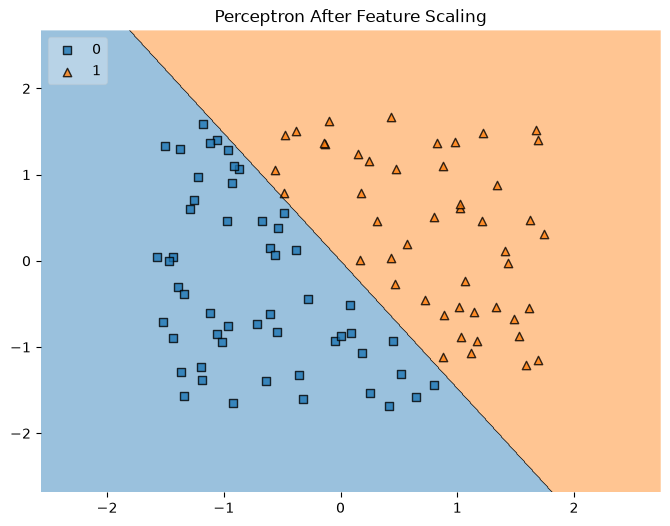

In [25]:
#Plot the Perceptron finally
plt.figure(figsize=(8, 6))
plot_decision_regions(X_scaled, y.values, clf=p, legend=2)
plt.title("Perceptron After Feature Scaling")
plt.show()